In [1]:
# Import Libraries and Load/Understand Data

import pandas as pd

df = pd.read_csv("superstore.csv", encoding="latin-1")

#understanding your dataset
print(df.shape)
print(df.dtypes)
df.head()

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Check for missing values and basic stats
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic statistics:")
df[["Sales","Quantity","Discount","Profit"]].describe()

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Basic statistics:


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [3]:
# Data Cleaning

# Drop useless column
df = df.drop(columns=["Row ID"])

# Fix date columns - convert from text to actual dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Extract useful time features from Order Date
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month

#Confirm the fixes
print(df[["Order Date", "Ship Date", "Order Year", "Order Month"]].head())
print("\nNew shape:", df.shape)

print(df.dtypes)

  Order Date  Ship Date  Order Year  Order Month
0 2016-11-08 2016-11-11        2016           11
1 2016-11-08 2016-11-11        2016           11
2 2016-06-12 2016-06-16        2016            6
3 2015-10-11 2015-10-18        2015           10
4 2015-10-11 2015-10-18        2015           10

New shape: (9994, 22)
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Year                int32
Order Month

## Sales vs Profit by Category

**Key Insights:** Technology and Office Supplies generate strong profits relative to their sales. Furniture, however, generates disproportionately low profit despite high sales volume - this could be due to heavy discounting or high operational costs in this category. In general, it appears that the company is generating well over $2.3m in sales and only making about $286k in profits, which is around 12% margin. Something is wrong and needs to be investigated. 

Text(0, 0.5, 'Total Profit ($)')

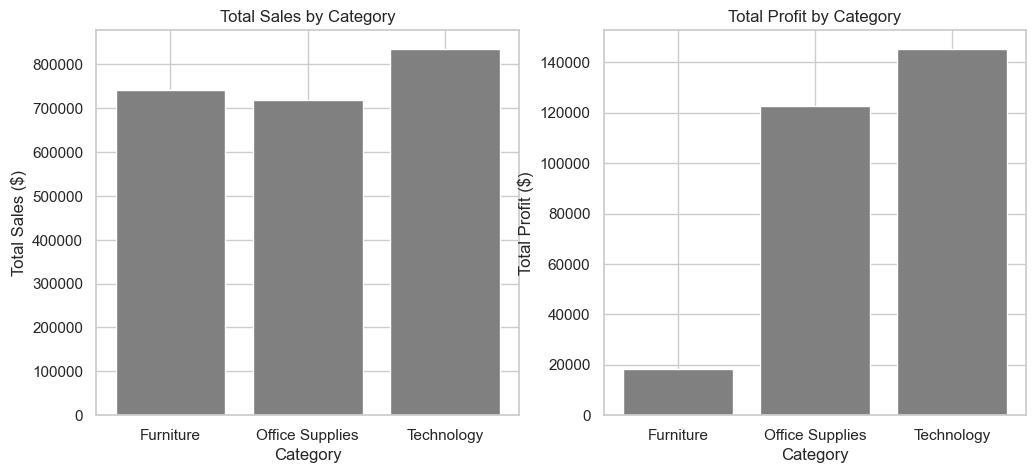

In [ ]:
# EDA - Sales and Profit by Category
# Which category generates the most sales and profit?
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Sales and Profit by Category
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Sales by Category
axes[0].bar(category_summary["Category"], category_summary["Sales"], color=["grey"])
axes[0].set_title("Total Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales ($)")

# Profit by Category
axes[1].bar(category_summary["Category"], category_summary["Profit"], color=["grey"])
axes[1].set_title("Total Profit by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Profit ($)")

plt.tight_layout()
plt.show()

print(category_summary)
